In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

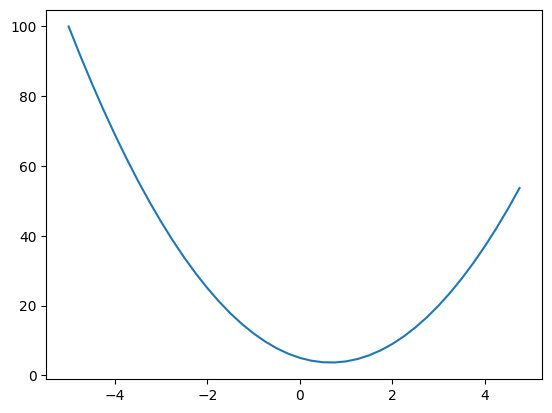

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [6]:
#calculating derivatives
h = 0.001
x = 3.0 #slope = 14.00300000000243 , if a negative value is taken of x , it wil be slightly less than 20 
# for this eqn the slope will be = 0 for x = 2/3
(f(x + h) - f(x))/ h #numerical appx

14.00300000000243

In [7]:
# a little more complex case 
a = 2.0 
b = -3.0
c = 10.0 
d = a*b + c  # a scalar with 3 inputs , so 3 inputs in our expression graph and a  single output D 
print(d)

4.0


In [8]:
# lets look at the derivatives of d wrt a,b,c . I need to understand that derivatives here mean , how much will the dependent value change with the slightest change in the independent nodes
h = 0.0001
a = 2.0 
b = -3.0
c = 10.0 

d1 = a*b + c
# LETS SEE THE CHANGE DUE TO a
a += h
d2 = a*b + c

print('d1',d1)
print('d2',d2)
print('slope', (d2- d1)/h) # change in how much the function increased when we bumped                            

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [45]:
class Value: #takes a single scalar value and keeps track of it 

    def __init__(self, data, _children=(), _op='', label=''): # 1)_children created as an empty tuple 
        self.data = data
        self.grad = 0.0 # variable to maintain the derivative
        self._backward = lambda: None
        self._prev = set(_children) # 2) BUT STORED AS EMPTY SET , after this we know the previous values , but not what operations where performed
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') #wrapping + of the data
        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data,(self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out 
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10, label='c')
                                                                        #a + b # currently python doesn't know how to add two different value object , so we define __add__
                                                                        # now after adding __add__ , python after examining the line a+b , will internally call a.__add__(b), so b is the other value object
                                                                        #define a * b 
                                                                        #a * b #python will internally call a.__mul__(b), o/p should be -6.0 , yes sirrrrrrrrrrrr
#forward pass 
e= a*b; e.label='e'
d = e + c ; d.label='d'#will internally call (a.__mul__(b).add(c)) 
f =Value(-2.0, label='f')
L = d*f ; L.label= 'L'
L

Value(data=-8.0)

In [10]:
# visualizing the graph/DS
from graphviz import Digraph

def trace(root):
    #build sets of all nodes and edges in a graph 
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges 

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR --> left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid =str(id(n))
        #for any value --> create rectangle using record
        dot.node(name =uid, label ="{%s | data %.4F | grad %.4f}" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

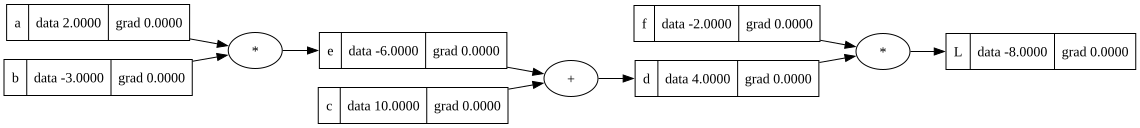

In [46]:
draw_dot(L)

1 node back propagation

L = d * f

 dL /dd = f = -2.0

 dL / df = d = 4.0 #proof in notes

In [12]:
# setting up grad value manually eby simple calculas, we cross check the value with the lol() functions answer

f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = (-2.0 * -3.0) # 6.0
b.grad = (-2.0 * 2.0) # -4.0

2 node backpropagation:

dL/dc = ?
1 step = dd / dc = 1.0
 
d = c+ e 
 
(f(x + h) - f(x))/h

(c +h +e -(c+e)/h)

(c + h +e - c- e)/h

h/h = 1.0 

dd / de  = 1.0

WANT : dL / dc  = (dl / dd) * (dd / dc) #chain rule

KNOW : dL / dd , dL / dc


3rd step bppg

dL / de = -2.0 

e = a* b 

da/de =? = b = -3.0 


WANT : dL / da 

dL/da = (dL/de) * (de/da)

In [29]:
def lol():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a*b; e.label='e'
    d = e + c ; d.label='d'#will internally call (a.__mul__(b).add(c)) 
    f = Value(-2.0, label='f')
    L = d*f ; L.label= 'L'
    L1 = L.data

    a = Value(2.0 , label='a')
    #a.data += h
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10, label='c')
    #c.data += h
    e = a*b; e.label='e'
    #e.data += h
    d = e + c ; d.label='d'#will internally call (a.__mul__(b).add(c)) 
    #d.data += h
    f = Value(-2.0 , label='f')
    L = d*f ; L.label= 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-3.9999999999995595


In [14]:
#seeing what if we nidge values little bit , what will happen to the total outcome 

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad




e= a*b 
d = e + c ;

L = d*f 
print(L.data)

# END OF 1ST MANUAL BACK PPG EXAMPLE 

-7.286496


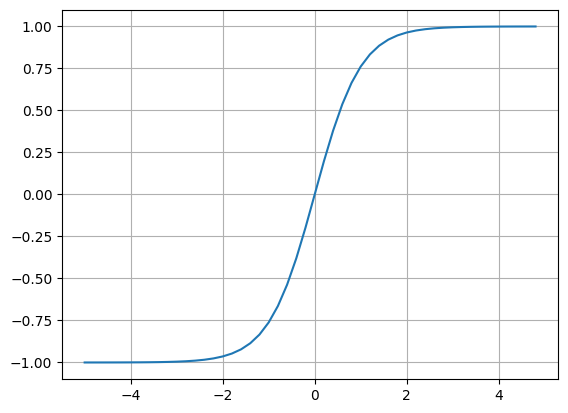

In [15]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid(); 
#tanh function is used as activation function for us
#because of the nature of the curve 

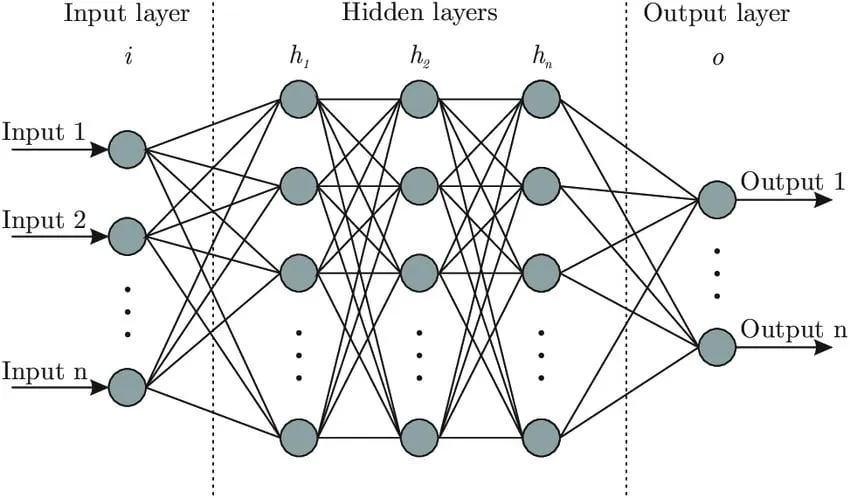    We replicate a neuron in the neural nets

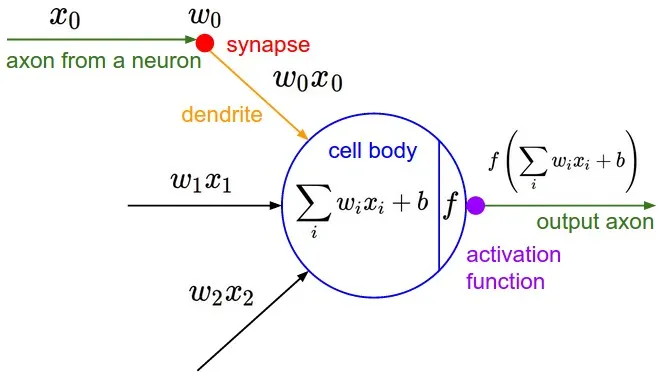 

We need to create a tanh() function , but tanh() is a hyperbolic curve . This will be the activation function . tanh is used because it taps out at values of +1 and -1

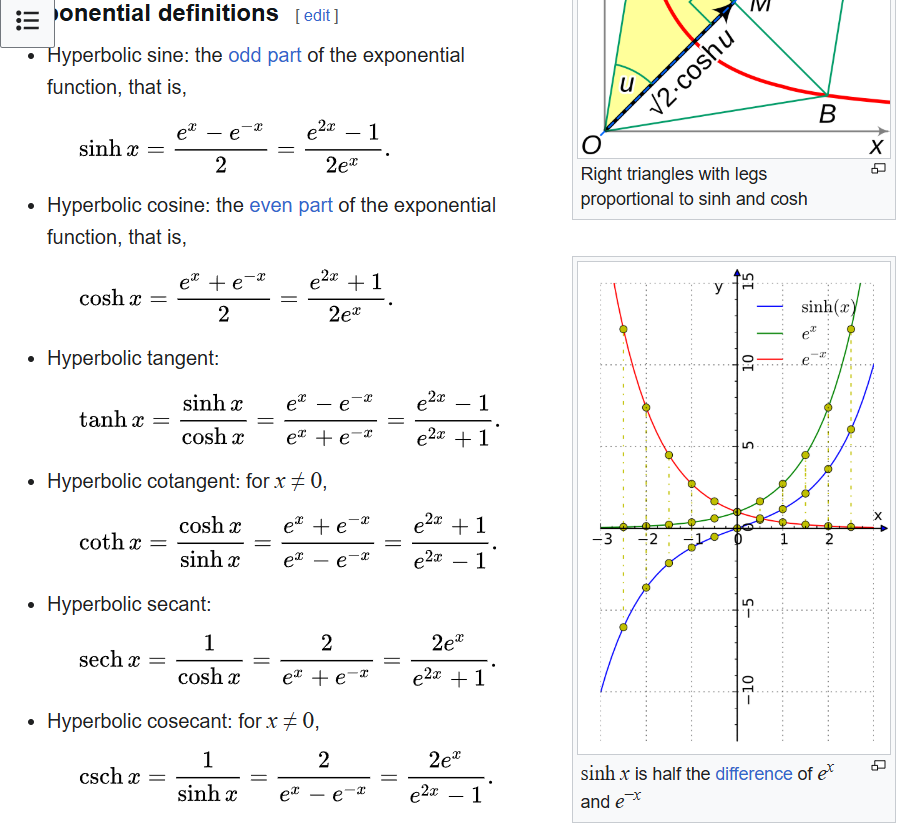

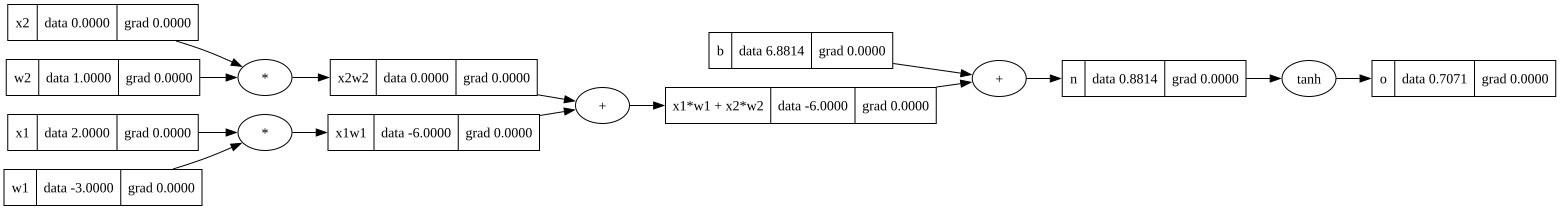

In [59]:
# inputs x1,x2
x1= Value(2.0, label='x1')
x2= Value(0.0, label= 'x2')
#weights w1,w2
w1= Value(-3.0, label='w1')
w2= Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1 ; x1w1.label='x1w1'
x2w2 = x2*w2 ; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'  #cell body function 
o = n.tanh(); o.label='o'
draw_dot(o)



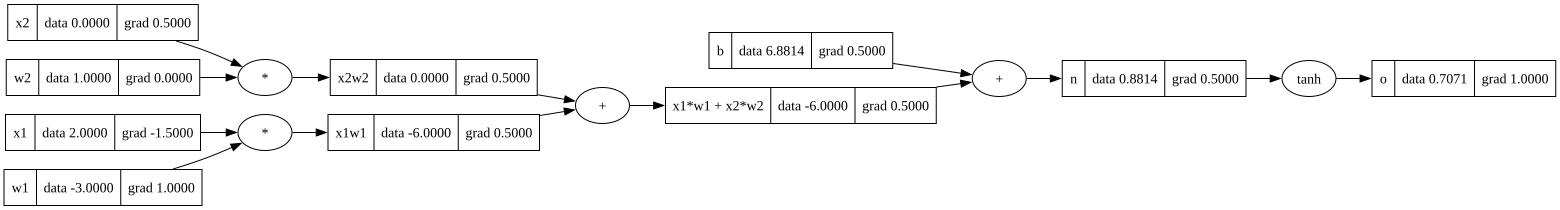

In [71]:
o.grad = 1.0 #derivative of o wrt o
draw_dot(o)

In [63]:
o._backward()

In [65]:
n._backward()

In [67]:
b._backward()

In [68]:
x1w1x2w2._backward()

In [70]:
x1w1._backward()
x2w2._backward()

In [28]:
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2
1 - o.data**2
n.grad = 0.5 #local derivative of o wrt n via tanh

In [ ]:
 # + OPERATOR , GRADIENT FLOWS EQUALLY
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5


In [ ]:
# * gradient 
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

# manual bppg of example 2 done
